# CIFAR10 EDA

CIFAR-10 is a dataset of 60,000 32x32 color images spanning 10 classes (6,000 images per class), widely used as a standard benchmark in machine learning research to evaluate the effectiveness of image-based models such as VAEs, GANs, and autoencoders. Through this exploratory data analysis, we aim to understand the dataset's structure and characteristics before building generative models on it.

In [2]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from torchvision.datasets import CIFAR10

In [3]:
import seaborn as sns

# Shared design system for all notebooks in dele/: a 10-color categorical palette
# (one hue per CIFAR10 class), validated for lightness, chroma, and colorblind
# separation with the dataviz skill's validator (all checks pass).
PALETTE = [
    "#A1533F",  # 0 airplane   - terracotta
    "#C08A3E",  # 1 automobile - ochre
    "#3D8049",  # 2 bird       - sage
    "#24558F",  # 3 cat        - slate blue
    "#8A3466",  # 4 deer       - plum
    "#4552A8",  # 5 dog        - indigo
    "#8C3F32",  # 6 frog       - brick red
    "#B79A2E",  # 7 horse      - mustard
    "#B5615B",  # 8 ship       - rose
    "#6B7A1A",  # 9 truck      - olive
]
sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams["figure.facecolor"] = "#fcfcfb"
plt.rcParams["axes.facecolor"] = "#fcfcfb"

## 1. Load Data

We load CIFAR10 via torchvision and perform some initial inspections, checking shapes, dtypes, and value ranges before any further analysis.

### 1.1 Load the Dataset

In [4]:
train_set = CIFAR10(root="..", train=True, download=True)
test_set = CIFAR10(root="..", train=False, download=True)

x_train, y_train = train_set.data, np.array(train_set.targets)
x_test, y_test = test_set.data, np.array(test_set.targets)

### 1.2 Inspect Shapes and Classes

In [5]:
class_names = train_set.classes

print("x_train:", x_train.shape, x_train.dtype)
print("y_train:", y_train.shape, y_train.dtype)
print("x_test: ", x_test.shape, x_test.dtype)
print("y_test: ", y_test.shape, y_test.dtype)
print("pixel range:", x_train.min(), "to", x_train.max())
print("classes:", class_names)

x_train: (50000, 32, 32, 3) uint8
y_train: (50000,) int64
x_test:  (10000, 32, 32, 3) uint8
y_test:  (10000,) int64
pixel range: 0 to 255
classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


### 1.3 Device Setup

One sentence noting we're selecting the GPU (if available) as the torch device here, since every model notebook downstream reuses this same pattern for training.

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


## 2. Class Balance

We check class imbalance to ensure that train and test image numbers remain consistent.

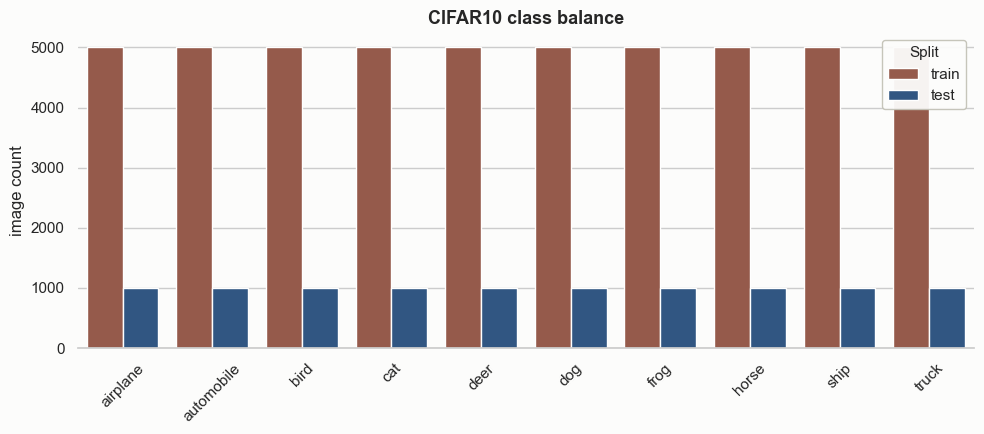

In [7]:
train_counts = np.bincount(y_train, minlength=len(class_names))
test_counts = np.bincount(y_test, minlength=len(class_names))

balance_df = pd.DataFrame({
    "class": list(class_names) * 2,
    "split": ["train"] * len(class_names) + ["test"] * len(class_names),
    "count": np.concatenate([train_counts, test_counts]),
})

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.barplot(data=balance_df, x="class", y="count", hue="split",
            palette=[PALETTE[0], PALETTE[3]], ax=ax)

ax.set_xlabel("")
ax.set_ylabel("image count")
ax.set_title("CIFAR10 class balance", fontsize=13, fontweight="bold")
ax.tick_params(axis="x", rotation=45)
sns.despine(left=True)
ax.legend(title="Split", frameon=True, framealpha=0.95, edgecolor="#c3c2b7",
          fontsize=11, title_fontsize=11, loc="upper right")
plt.tight_layout()
plt.show()

## 3. Visualize Sample Images

We visualize a sample of images from each class to inspect their visual appearance and the range of classes present in the dataset.

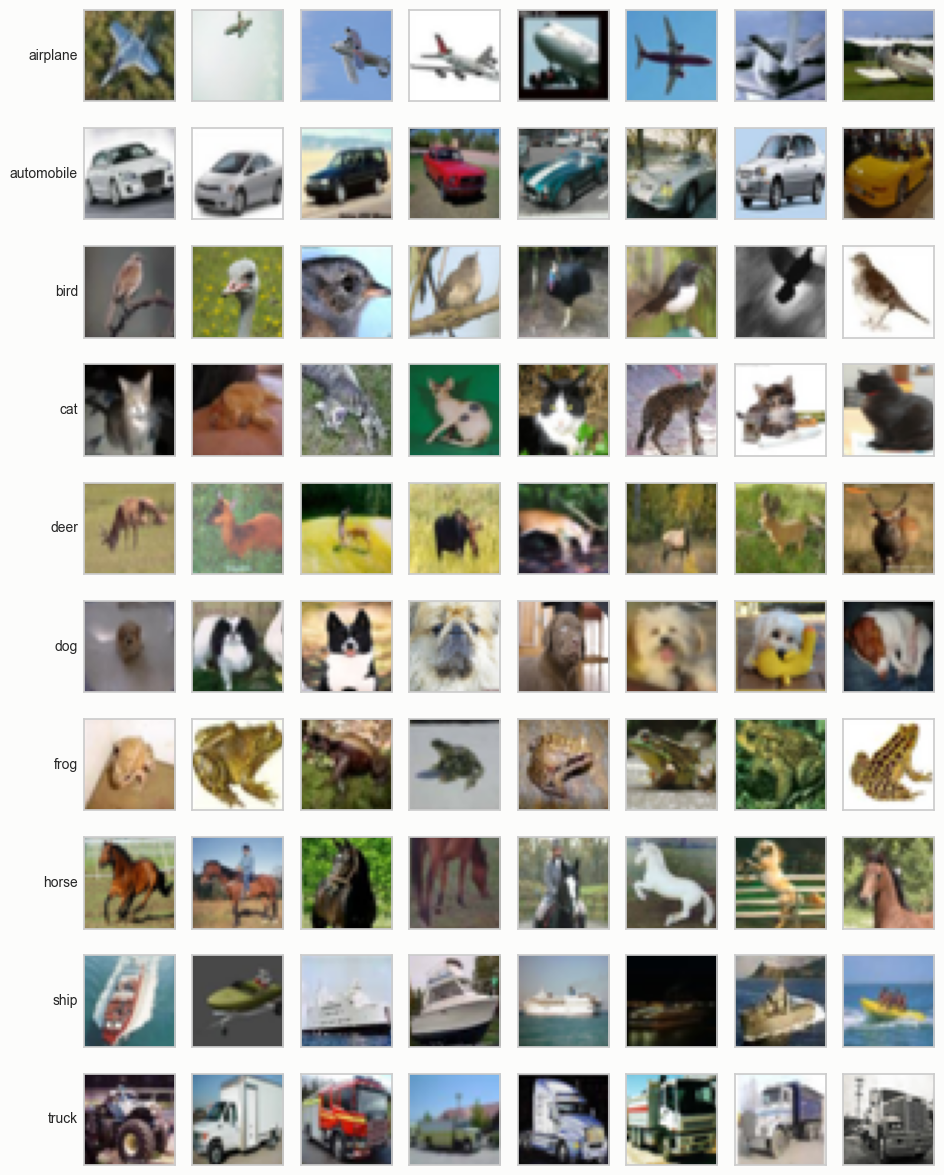

In [8]:
# One row per class, 8 randomly sampled images per row, labelled with the class name.
n_samples = 8
rng = np.random.default_rng(42)

fig, axes = plt.subplots(len(class_names), n_samples,
                          figsize=(n_samples * 1.2, len(class_names) * 1.2))

for class_idx, class_name in enumerate(class_names):
    class_indices = np.where(y_train == class_idx)[0]
    sample_indices = rng.choice(class_indices, size=n_samples, replace=False)
    for col, img_idx in enumerate(sample_indices):
        ax = axes[class_idx, col]
        ax.imshow(x_train[img_idx])
        ax.set_xticks([])
        ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(class_name, rotation=0, ha="right", va="center", fontsize=10)

plt.tight_layout()
plt.show()

## 4. Pixel Value Distribution

We check that all pixel values fall within the expected range of 0 to 255, to confirm the data is valid ahead of normalizing it to a 0-1 scale during preprocessing.

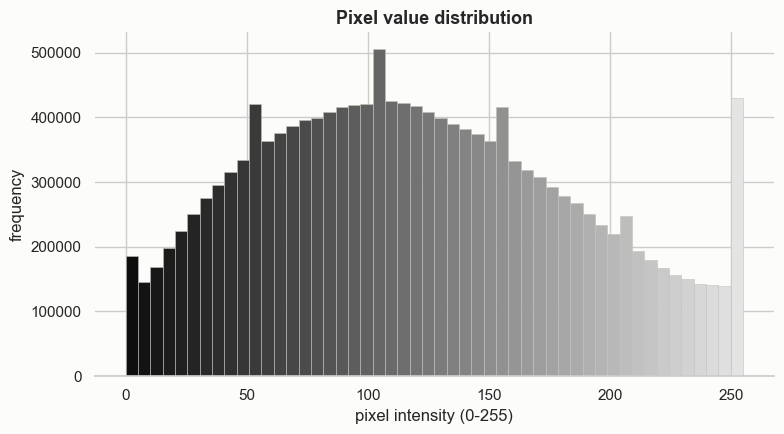

In [9]:
sample_size = 5000
n_bins = 50
rng = np.random.default_rng(42)
sample_pixels = x_train[rng.choice(len(x_train), size=sample_size, replace=False)].ravel()

counts, bin_edges = np.histogram(sample_pixels, bins=n_bins, range=(0, 255))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Bin color follows its own intensity (black to white), since the x-axis is literally pixel brightness.
bin_gray = bin_centers / 255
bar_colors = plt.cm.gray(bin_gray * 0.85 + 0.05)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(bin_centers, counts, width=(bin_edges[1] - bin_edges[0]),
       color=bar_colors, edgecolor="#c3c2b7", linewidth=0.4)

ax.set_xlabel("pixel intensity (0-255)")
ax.set_ylabel("frequency")
ax.set_title("Pixel value distribution", fontsize=13, fontweight="bold")
sns.despine(left=True)
plt.tight_layout()
plt.show()

### Conclusion

This histogram shows pixel intensities spread across most of the 0-255 range, consistent with a natural, real-world photographic dataset rather than a synthetic or narrowly constrained one. This confirms that scaling pixel values to a 0-1 range is an appropriate preprocessing step before modeling, and that no further value-range cleaning is required for CIFAR10.

## 5. Per-Channel Statistics

We also explore further statistics about the dataset itself, specifically the distribution of the image color channels (R, G, B).

Overall channel mean (R, G, B): [125.31 122.95 113.87]
Overall channel std  (R, G, B): [62.99 62.09 66.7 ]


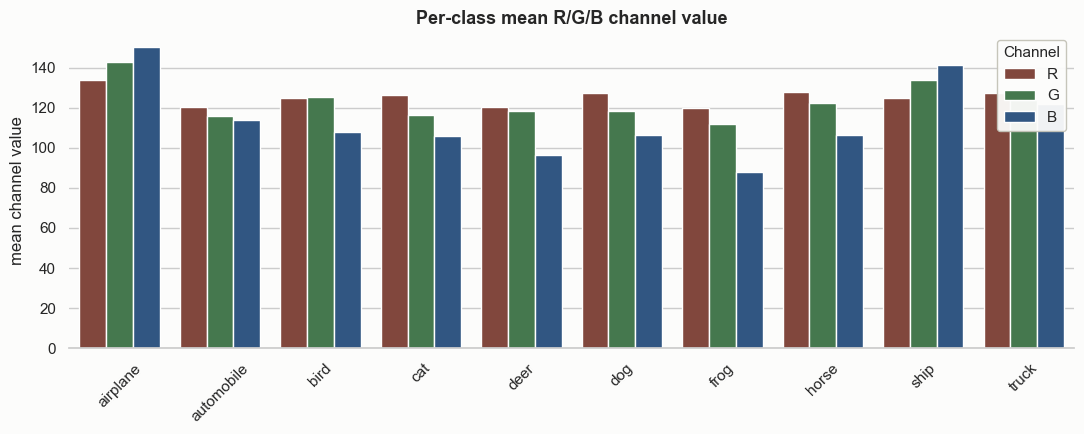

In [10]:
overall_means = x_train.reshape(-1, 3).mean(axis=0)
overall_stds = x_train.reshape(-1, 3).std(axis=0)
print("Overall channel mean (R, G, B):", overall_means.round(2))
print("Overall channel std  (R, G, B):", overall_stds.round(2))

channel_stats = []
for class_idx, class_name in enumerate(class_names):
    class_images = x_train[y_train == class_idx]
    for c, channel in enumerate(["R", "G", "B"]):
        channel_stats.append({
            "class": class_name,
            "channel": channel,
            "mean": class_images[..., c].mean(),
        })

channel_df = pd.DataFrame(channel_stats)

fig, ax = plt.subplots(figsize=(11, 4.5))
sns.barplot(data=channel_df, x="class", y="mean", hue="channel",
            palette=[PALETTE[6], PALETTE[2], PALETTE[3]], ax=ax)

ax.set_xlabel("")
ax.set_ylabel("mean channel value")
ax.set_title("Per-class mean R/G/B channel value", fontsize=13, fontweight="bold")
ax.tick_params(axis="x", rotation=45)
sns.despine(left=True)
ax.legend(title="Channel", frameon=True, framealpha=0.95, edgecolor="#c3c2b7",
          fontsize=11, title_fontsize=11, loc="upper right")
plt.tight_layout()
plt.show()

### Conclusion

This chart shows the mean R, G, and B channel value for each class. A class whose bars differ noticeably from the others indicates a dominant color tone, while similar bars across channels indicate a more neutral or mixed color profile.

## 6. Visual Complexity per Class

We use pixel-wise variance to measure how visually diverse each class is relative to the others.

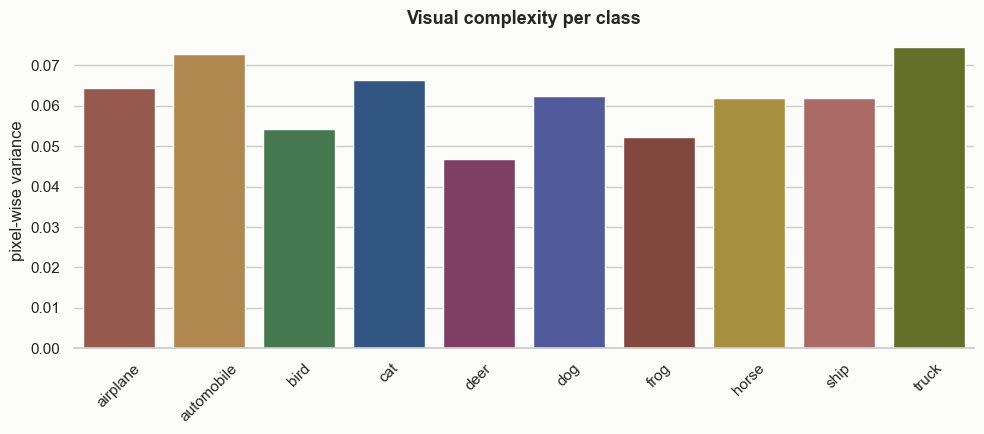

In [11]:
class_variances = []
for class_idx in range(len(class_names)):
    class_images = x_train[y_train == class_idx].astype(np.float64) / 255
    class_variances.append(class_images.var())

variance_df = pd.DataFrame({"class": class_names, "variance": class_variances})

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.barplot(data=variance_df, x="class", y="variance", hue="class",
            palette=PALETTE, legend=False, ax=ax)

ax.set_xlabel("")
ax.set_ylabel("pixel-wise variance")
ax.set_title("Visual complexity per class", fontsize=13, fontweight="bold")
ax.tick_params(axis="x", rotation=45)
sns.despine(left=True)
plt.tight_layout()
plt.show()

### Conclusion

Truck has the highest pixel-wise variance and automobile the lowest, indicating that truck images vary more in color, background, and shape, while automobile images are visually more consistent. Classes with higher variance, such as truck, are likely harder for a generative model to learn and reproduce accurately, while lower-variance classes like automobile should be comparatively easier to generate.

## 7. Mean Image per Class

We compute the average (mean) image for each class to reveal consistent color or shape features shared across that class.

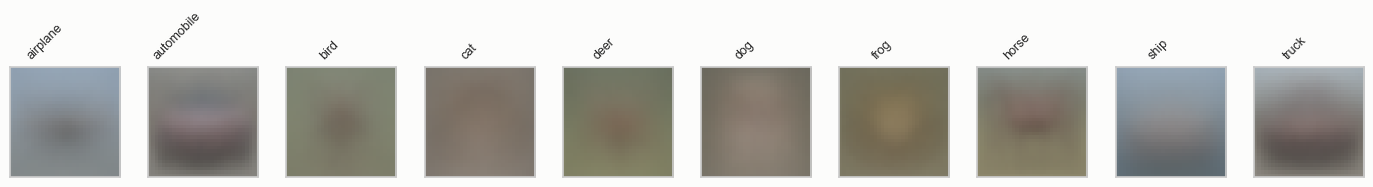

In [12]:
fig, axes = plt.subplots(1, len(class_names), figsize=(len(class_names) * 1.4, 1.8))

for class_idx, class_name in enumerate(class_names):
    class_images = x_train[y_train == class_idx]
    mean_image = class_images.mean(axis=0) / 255
    axes[class_idx].imshow(mean_image)
    axes[class_idx].set_xticks([])
    axes[class_idx].set_yticks([])
    axes[class_idx].set_title(class_name, fontsize=9, rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Conclusion

Every class produces a blurred, low-detail image rather than a recognizable shape, confirming that CIFAR10 objects are not spatially aligned across a class (varying position, pose, and scale wash out fine structure when averaged). Even so, a few consistent color tendencies remain visible: airplane, ship, and cat lean blue-gray, consistent with sky or water backgrounds; automobile, deer, and truck retain a faint warm reddish-brown blob near the center, suggesting a fairly consistent object color and position; and frog stands out with a distinct yellow-green tone, likely from its typical pond or grassy environment. This suggests the mean image is a better indicator of a class's background/color palette than its shape, and that classes with a visible central blob (automobile, deer, truck) may be marginally easier for a generative model to anchor onto than classes that reduce to a nearly uniform wash.

## 8. Class Similarity Heatmap

We compute the pairwise distance between each class's mean image and display it as a heatmap, allowing us to visually see how similar or correlated each class is with another.

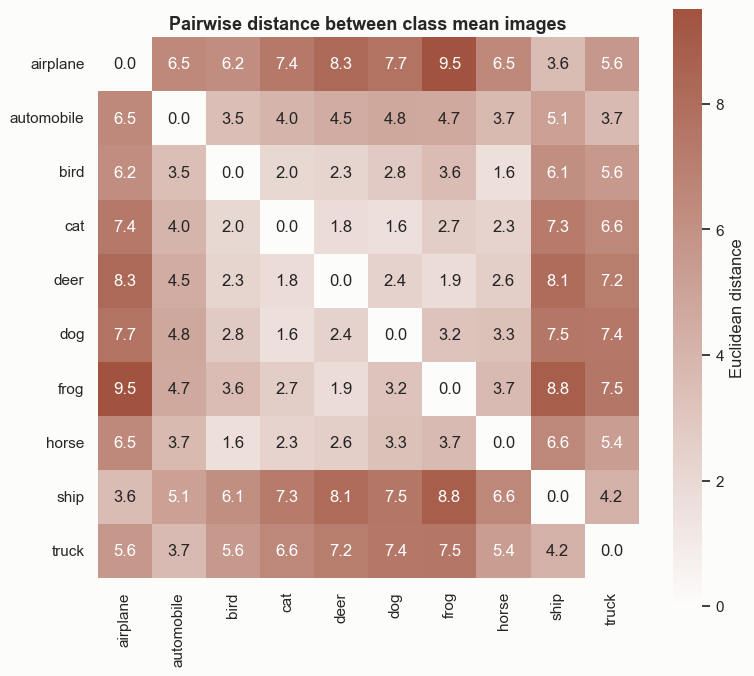

In [13]:
mean_images = np.array([
    x_train[y_train == class_idx].mean(axis=0).ravel() / 255
    for class_idx in range(len(class_names))
])

n_classes = len(class_names)
distances = np.zeros((n_classes, n_classes))
for i in range(n_classes):
    for j in range(n_classes):
        distances[i, j] = np.linalg.norm(mean_images[i] - mean_images[j])

# Sequential, single-hue colormap (surface to terracotta) since this encodes magnitude, not identity.
seq_cmap = LinearSegmentedColormap.from_list("seq_terracotta", ["#fcfcfb", PALETTE[0]])

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(distances, xticklabels=class_names, yticklabels=class_names,
            cmap=seq_cmap, annot=True, fmt=".1f", square=True,
            cbar_kws={"label": "Euclidean distance"}, ax=ax)

ax.set_title("Pairwise distance between class mean images", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Conclusion

Frog and airplane sit furthest apart at around 9.5, the most dissimilar pair, consistent with their contrasting mean-image tones from Section 7 (frog's yellow-green versus airplane's blue-gray). Ship and airplane sit closest together, the most similar pair, which matches their shared blue-gray, sky/water-toned backgrounds. Most other class pairs fall in a middle range of around 6-7, indicating moderate differentiation overall. We will check in Section 9 whether the PCA/t-SNE scatter agrees with these same closest and furthest pairs.

## 9. Class Separability (PCA / t-SNE Scatter)

We use PCA and t-SNE to perform dimensionality reduction, projecting the images into a 2D space so we can visually inspect which classes cluster together and which classes overlap.

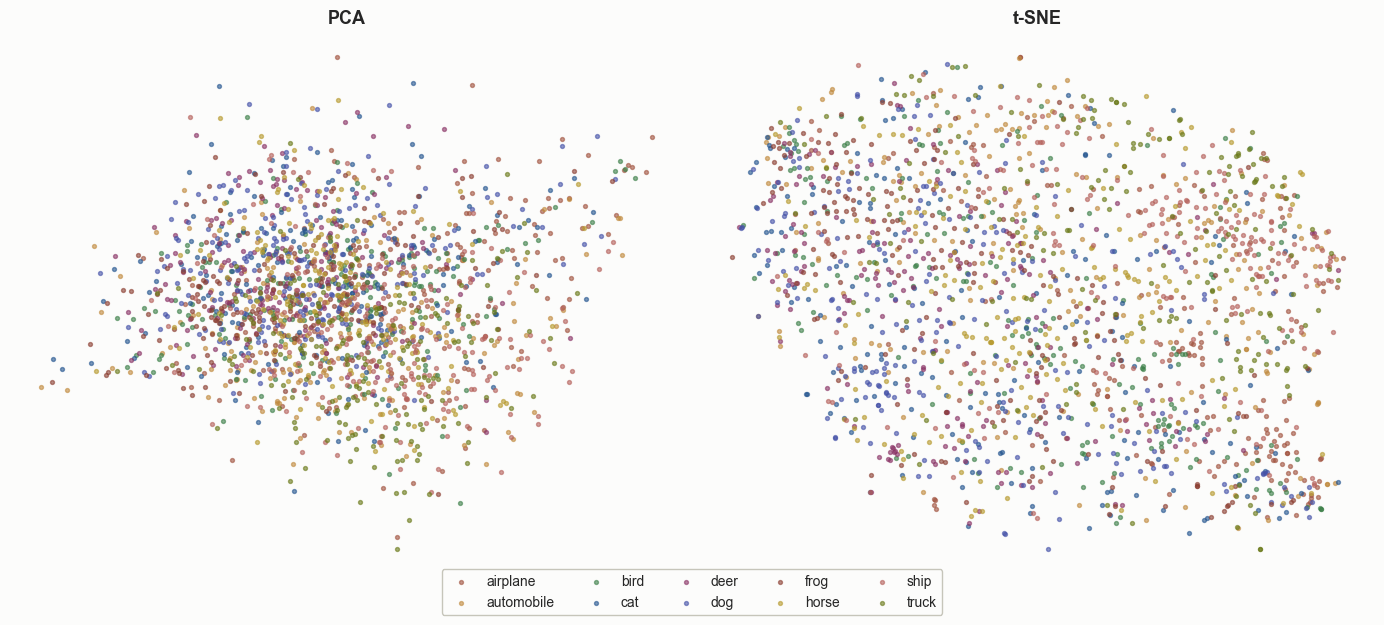

In [14]:
sample_size = 2000
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(x_train), size=sample_size, replace=False)
flat_sample = x_train[sample_idx].reshape(sample_size, -1) / 255
labels_sample = y_train[sample_idx]

pca_coords = PCA(n_components=2, random_state=42).fit_transform(flat_sample)
tsne_coords = TSNE(n_components=2, random_state=42, init="pca").fit_transform(flat_sample)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, coords, title in zip(axes, [pca_coords, tsne_coords], ["PCA", "t-SNE"]):
    for class_idx, class_name in enumerate(class_names):
        mask = labels_sample == class_idx
        ax.scatter(coords[mask, 0], coords[mask, 1], s=8, alpha=0.6,
                   color=PALETTE[class_idx], label=class_name)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xticks([])
    ax.set_yticks([])

handles, labels_ = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_, loc="lower center", ncol=5, frameon=True,
           framealpha=0.95, edgecolor="#c3c2b7", fontsize=10, bbox_to_anchor=(0.5, -0.05))
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

### Conclusion

Neither PCA nor t-SNE shows meaningful class separation in raw pixel space, classes overlap heavily in both projections. This is expected: pixel-level similarity is dominated by low-level factors (background, lighting, color) rather than the semantic features that define a class, which is why conv-based encoders, not flattened pixels, are needed to capture class-relevant structure. This also implies that a "does this generated image look pixel-similar to real images" test would be a weak evaluation metric on its own, supporting the choice to lean on eye-test scoring and FID (which uses learned InceptionV3 features, not raw pixels) rather than pixel distance metrics.

## 10. Color vs. Grayscale Preview

We compare color and grayscale versions of the images to get a preliminary sense of whether building a model on black-and-white images could produce better results.

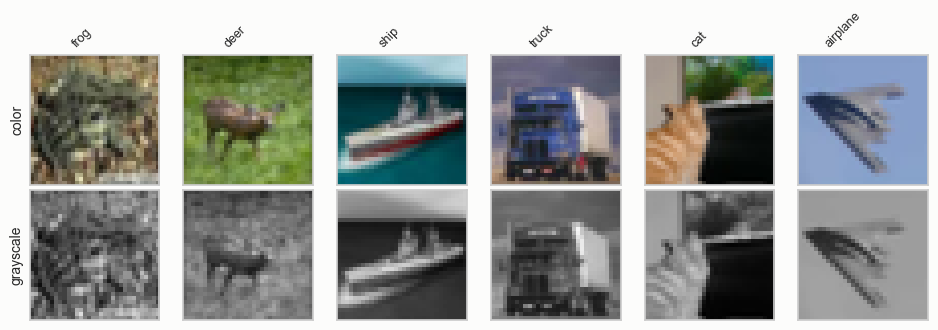

In [16]:
# One column per sampled class, color on top row and its grayscale conversion below.
n_preview = 6
rng = np.random.default_rng(42)
preview_classes = rng.choice(len(class_names), size=n_preview, replace=False)

fig, axes = plt.subplots(2, n_preview, figsize=(n_preview * 1.6, 3.4))

for col, class_idx in enumerate(preview_classes):
    class_images = x_train[y_train == class_idx]
    img = class_images[rng.integers(len(class_images))]
    gray = img @ [0.299, 0.587, 0.114]

    axes[0, col].imshow(img)
    axes[0, col].set_title(class_names[class_idx], fontsize=9, rotation=45, ha="right")
    axes[1, col].imshow(gray, cmap="gray", vmin=0, vmax=255)

    for row in range(2):
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])

axes[0, 0].set_ylabel("color", fontsize=10)
axes[1, 0].set_ylabel("grayscale", fontsize=10)

plt.tight_layout()
plt.show()

### Conclusion

Converting to grayscale loses color information that can distinguish otherwise similarly shaped classes. For example, frog stood out in Section 7's mean images mainly through its distinct yellow-green tone rather than a unique shape, so that cue disappears once color is removed, potentially making it harder to distinguish from other classes with a similar silhouette. This suggests grayscale generation may be harder for classes that rely more on color than shape to be told apart, a prediction tested empirically in `vae_improvement.ipynb`'s color vs. grayscale experiment.

## 11. EDA Summary

This EDA set out to understand CIFAR10 before building generative models on it: confirming the dataset needs no cleaning, checking class balance, inspecting pixel value ranges and per-channel color statistics, measuring visual complexity and similarity across classes, and grounding the assignment's color-vs-grayscale question in an actual side-by-side comparison. All of these objectives were met, and the dataset was confirmed to be a clean, exactly balanced benchmark requiring no further preprocessing beyond normalization and label encoding.

The key insights are that classes differ meaningfully in visual complexity and color signature rather than in raw pixel separability. Truck showed the highest pixel-wise variance and automobile the lowest, suggesting truck will be harder to generate consistently. Mean images revealed that most classes reduce to a color/background blob rather than a recognizable shape, with frog standing out through a distinct yellow-green tone and airplane/ship sharing the closest similarity through blue-gray sky and water tones. Neither PCA nor t-SNE showed meaningful class clustering in raw pixel space, confirming that pixel-level similarity is a poor proxy for class identity and that learned, conv-based features are needed instead. Grayscale conversion was also shown to strip out exactly the kind of color cue (like frog's hue) that helps distinguish classes with similar shapes.

Overall, this EDA motivates several concrete modeling choices carried into the later notebooks: normalize pixels without needing to clean the data, use conv-based encoders/decoders rather than flattened dense layers, favor evaluation methods that rely on learned features (eye-test scoring, FID) over raw pixel distance, and expect classes with high visual variance (e.g. truck) to be harder to generate than low-variance classes (e.g. automobile). The color-vs-grayscale question raised here is left as a prediction, to be tested empirically in `vae_improvement.ipynb`.